In [2]:
from torchvision.utils import save_image
import torch
from tqdm import trange
from model import Unet

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device) # cuda is recommand

@torch.no_grad()
def generate_and_save(model, T, img_name='L.jpg', gen_N=64, chan=3, resolu=(28, 28)):
    alpha = (1-torch.linspace(1e-4, 2e-2, T)).reshape((-1, 1)).to(device)
    alpha_bar = torch.cumprod(alpha, 0).to(device)
    sigma = torch.sqrt(torch.linspace(1e-4, 2e-2, T).reshape((-1, 1))).to(device)
    # print(ALPHA.shape, ALPHA_BAR.shape, SIGMA.shape)
    # print(ALPHA[0:5]) 
    # print(ALPHA_BAR[0:5])
    # print(SIGMA[0:5])
    # return 0
    model.eval()
    
    L = []

    # ----- TODO ----- #
    # Sample gaussian noise X_T (5%). Please see DDPM paper https://arxiv.org/pdf/2006.11239.pdf or the link in the homework pdf file 
    X_T = torch.randn(gen_N, chan, resolu[0], resolu[1]).to(device)
    # print(X_T.shape)
    # return 0
    # ----- TODO ----- #

    for t in (bar := trange(T-1, -1, -1)):

        bar.set_description(f'[Denoising] step: {t}')

        # ----- TODO ----- #
        # Sampling: Please see DDPM paper https://arxiv.org/pdf/2006.11239.pdf or the link in the homework pdf file 
        
        z = torch.randn_like(X_T).to(device)
        predicted_noise = model(X_T,torch.tensor([t]).to(device))
        X_T = 1/torch.sqrt(alpha[t]) * (X_T - (1-alpha[t])/torch.sqrt(1-alpha_bar[t]) * predicted_noise) + sigma[t] * z
        

        # ----- TODO ----- #

        if t < 1:
            L.append(X_T)
    
    save_image(torch.cat(L)/2+0.5, img_name)

cuda


In [3]:
T = 1000   # 500 or 1000
model = Unet(in_channels=3).to(device)
state_dict = torch.load(f'checkpoint_{T}.pt')
model.load_state_dict(state_dict['model_state_dict'])
generate_and_save(model, T, gen_N=64, resolu=(64, 64), img_name=f'T{T}.jpg')

[Denoising] step: 0: 100%|██████████| 1000/1000 [03:22<00:00,  4.95it/s] 


# Draw some generated samples based on diffusion steps T = 500 and T = 1000. We will provide the pre-trained weights which are trained with 500 and 1000 steps. Hint: In the paper, the steps start at 1.

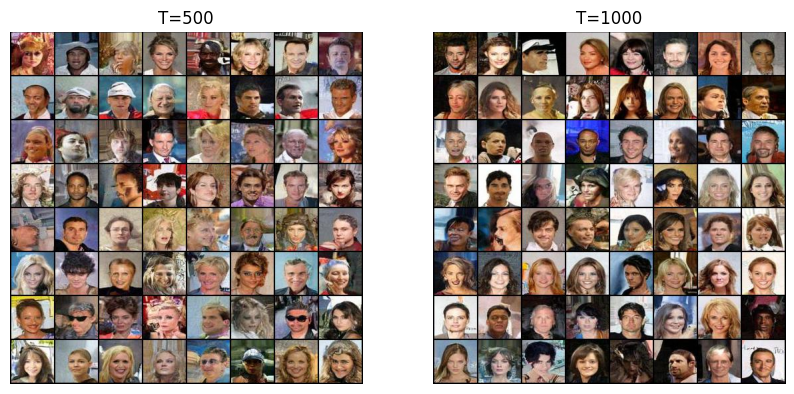

In [1]:
import matplotlib.pyplot as plt

img_500 = plt.imread('T500.jpg')
img_1000 = plt.imread('T1000.jpg')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_500)
plt.title('T=500')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_1000)
plt.title('T=1000')
plt.axis('off')
plt.show()

# Discuss the results based on different diffusion steps.
在DDPM中，diffusion steps的數量由 T 控制。
當 T 較小時，生成的圖像樣本可能會比較模糊，像素值的變化較小，細節不夠豐富，並且容易出現噪點，在逆向擴散過程中難以準確地恢復細節。
這時提高 T 的數值，可以讓生成的圖像樣本會更清晰，細節更豐富。然而，過高的T值可能導致overfitting，使得生成的圖像與訓練數據過於相似，缺乏多樣性。
